# InceptionV3 — Partial Fine-Tuning  
**Phase 1: Baseline Evaluation**  
This notebook evaluates the InceptionV3 model with partial fine-tuning applied (Mixed_7c branches). 

InceptionV3 (conservative): 1,874,994 / 25,214,714 parameters trainable (7.4%)


Epoch 1/5: 100%|██████████| 225/225 [29:24<00:00,  7.84s/it]


Epoch 1: Train Acc: 69.96%, Val Acc: 91.20%


Epoch 2/5: 100%|██████████| 225/225 [31:10<00:00,  8.31s/it]


Epoch 2: Train Acc: 88.17%, Val Acc: 91.20%


...

Epoch 3: Train Acc: 90.56%, Val Acc: 92.00%


Epoch 4/5: 100%|██████████| 225/225 [36:27<00:00,  9.72s/it]


Epoch 4: Train Acc: 92.72%, Val Acc: 90.80%


Epoch 5/5: 100%|██████████| 225/225 [31:57<00:00,  8.52s/it]


Epoch 5: Train Acc: 94.21%, Val Acc: 92.00%


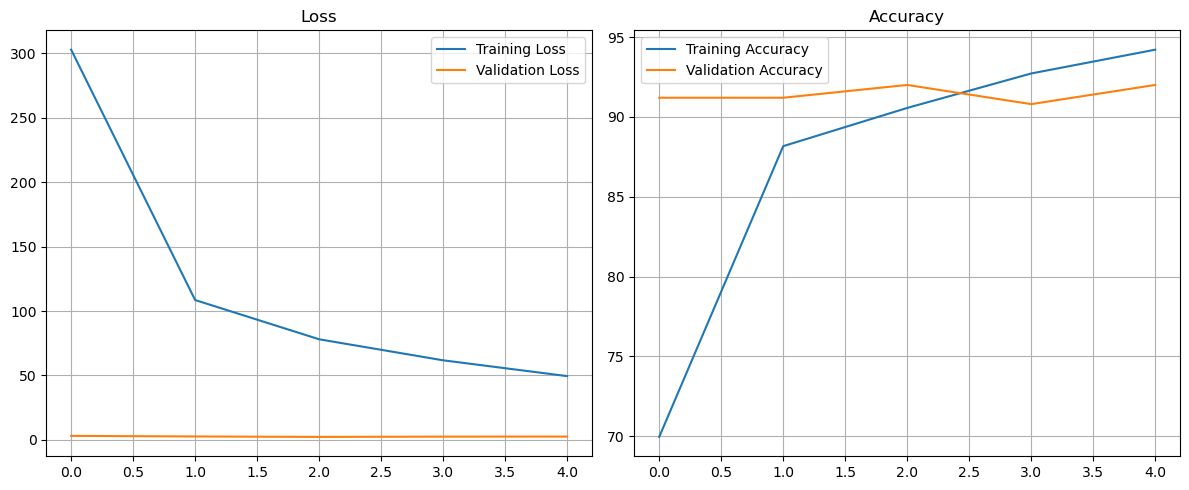

Test Accuracy: 94.40%
Classification Report:
                           precision    recall  f1-score   support

     ARCIGERA FLOWER MOTH       1.00      0.80      0.89         5
               ATLAS MOTH       1.00      1.00      1.00         5
        BANDED TIGER MOTH       1.00      0.80      0.89         5
  BIRD CHERRY ERMINE MOTH       0.83      1.00      0.91         5
        BLACK RUSTIC MOTH       1.00      1.00      1.00         5
             BLAIRS MOCHA       0.80      0.80      0.80         5
    BLOTCHED EMERALD MOTH       1.00      1.00      1.00         5
BLUE BORDERED CARPET MOTH       1.00      1.00      1.00         5
            CINNABAR MOTH       1.00      1.00      1.00         5
           CLEARWING MOTH       1.00      0.80      0.89         5
               COMET MOTH       1.00      1.00      1.00         5
    DEATHS HEAD HAWK MOTH       0.71      1.00      0.83         5
       ELEPHANT HAWK MOTH       1.00      1.00      1.00         5
         EMPEROR

In [ ]:
# Import necessary packages
# Core imports
from pathlib import Path
import os

# Numerics
import numpy as np

# Plotting (for training/validation curves)
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Torchvision
from torchvision import datasets, transforms, models

# Progress bar (for training loop)
from tqdm import tqdm

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Device - tells PyTorch code to automatically select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Paths
data_root = Path("../data/kaggle-dataset/archive")

# Transforms - InceptionV3 expects input size of 299x299
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dictionary-style dataset and dataloader setup
data_transforms = {
    'train': transform,
    'valid': transform,
    'test': transform
}

image_datasets = {
    split: datasets.ImageFolder(os.path.join(data_root, split), transform=data_transforms[split])
    for split in ['train', 'valid', 'test']
}

dataloaders = {
    split: DataLoader(image_datasets[split], batch_size=32, shuffle=(split == 'train'), num_workers=4)
    for split in ['train', 'valid', 'test']
}

class_names = image_datasets['train'].classes
num_classes = len(class_names)

# Load InceptionV3 model with pretrained weights
model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)

# Replace the final classification layer 
model.fc = nn.Linear(model.fc.in_features, num_classes)

# More conservative InceptionV3 fine-tuning
for name, param in model.named_parameters():
    # Only unfreeze specific smaller parts of Mixed_7c
    if (("Mixed_7c.branch3x3_2" in name or "Mixed_7c.branch3x3dbl_3" in name) 
        or name.startswith("fc")):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Check fine-tuning
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"InceptionV3 (conservative): {trainable:,} / {total:,} parameters trainable ({100*trainable/total:.1f}%)")

model.to(device)

# Loss and optimiser for calculating error and adjusting for model improvement
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)

# Training
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for x, y in tqdm(dataloaders['train'], desc=f"Epoch {epoch+1}/{epochs}"):
        x, y = x.to(device), y.to(device)
        optimiser.zero_grad()
        outputs, _ = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimiser.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == y).sum().item()
        total_samples += y.size(0)

    train_loss_list.append(total_loss)
    train_acc_list.append(100 * total_correct / total_samples)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for x, y in dataloaders['valid']:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_loss_list.append(val_loss)
    val_acc_list.append(100 * val_correct / val_total)

    print(f"Epoch {epoch+1}: Train Acc: {train_acc_list[-1]:.2f}%, Val Acc: {val_acc_list[-1]:.2f}%")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label="Training Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label="Training Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

# Test evaluation
model.eval()
all_preds, all_labels = [], []
test_correct, test_total = 0, 0

with torch.no_grad():
    for x, y in dataloaders['test']:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        pred = outputs.argmax(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        test_correct += (pred == y).sum().item()
        test_total += y.size(0)

print(f"Test Accuracy: {100 * test_correct / test_total:.2f}%")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confused pairs
cm = confusion_matrix(all_labels, all_preds)
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
confused = np.argwhere(cm_copy > 0)

print("Confused Class Pairs:")
for i, (true, pred) in enumerate(confused):
    count = cm[true, pred]
    print(f"{i+1}. True: {class_names[true]} ↔ Pred: {class_names[pred]} ({count} times)")

## Visualising Confused Pairs  

Confused species pairs identified from the confusion matrix are visualised below. For each pair, example images from the true class (top row) and the predicted class (bottom row) are displayed side by side to illustrate morphological similarities that may have led to misclassification.  

In [1]:
# Imports for visualisation
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_confused_species(dataset_dir, confused_pairs, n_samples=3):
    """
    Display sample images of species the model confused with one another.
    """
    test_dir = Path(dataset_dir) / "test"

    for true_class, pred_class in confused_pairs:
        print(f"\nConfused: '{true_class}' predicted as '{pred_class}'")
        fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 5))

        for row, class_name in enumerate([true_class, pred_class]):
            imgs = list((test_dir / class_name).glob("*"))
            samples = random.sample(imgs, min(n_samples, len(imgs)))
            for i, ax in enumerate(axes[row]):
                if i < len(samples):
                    ax.imshow(Image.open(samples[i]))
                    ax.set_title(class_name, fontsize=9)
                ax.axis("off")

        plt.suptitle(f"'{true_class}' ↔ '{pred_class}'", fontsize=12)
        plt.tight_layout()
        plt.show()


Confused: 'ARCIGERA FLOWER MOTH' predicted as 'DEATHS HEAD HAWK MOTH'


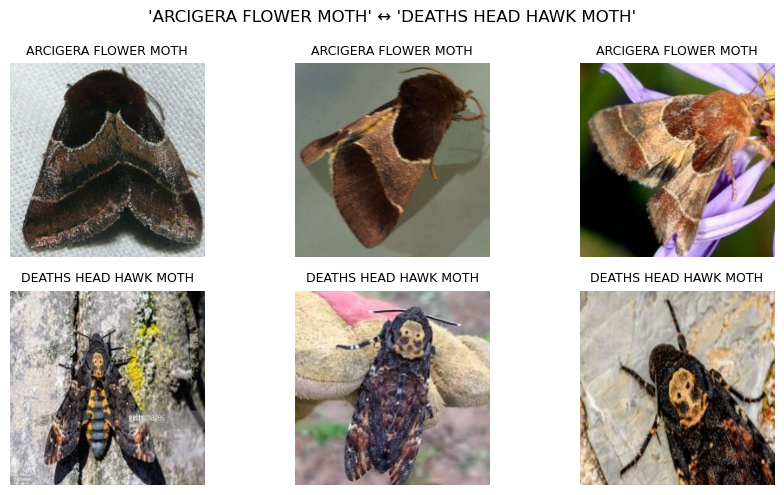


Confused: 'BANDED TIGER MOTH' predicted as 'GARDEN TIGER MOTH'


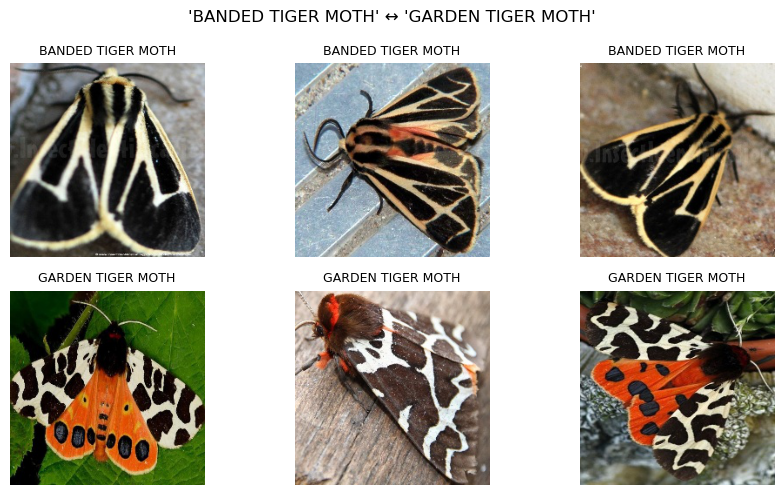


Confused: 'BLAIRS MOCHA' predicted as 'LACE BORDER MOTH'


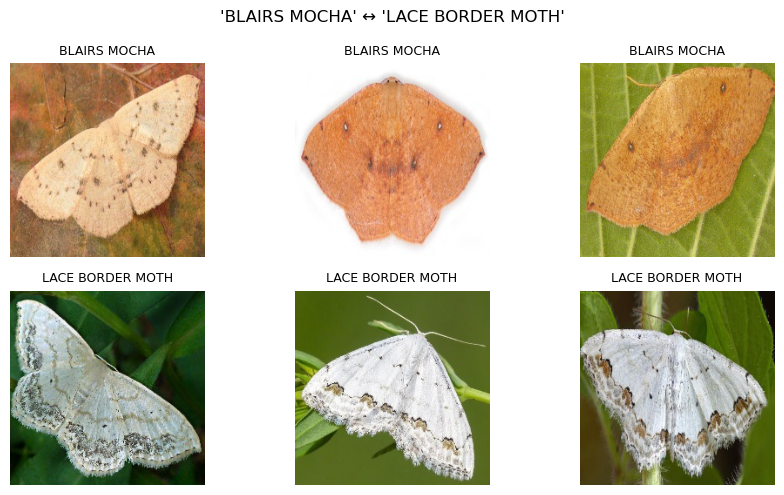


Confused: 'CLEARWING MOTH' predicted as 'FIERY CLEARWING MOTH'


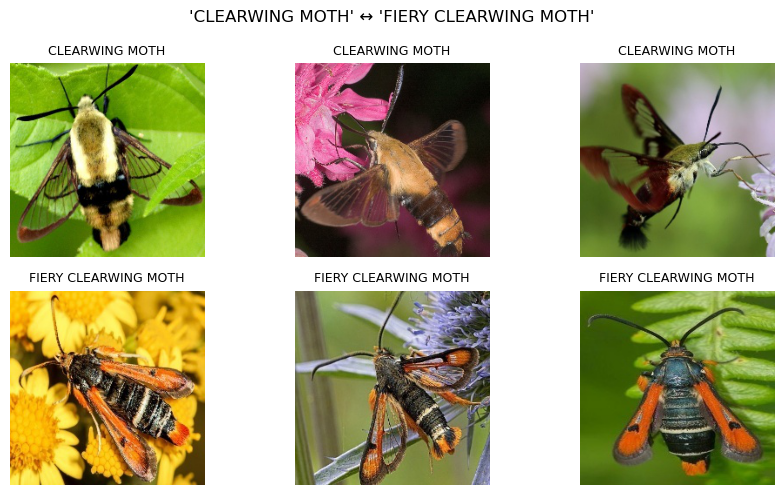


Confused: 'EMPEROR GUM MOTH' predicted as 'EMPEROR MOTH'


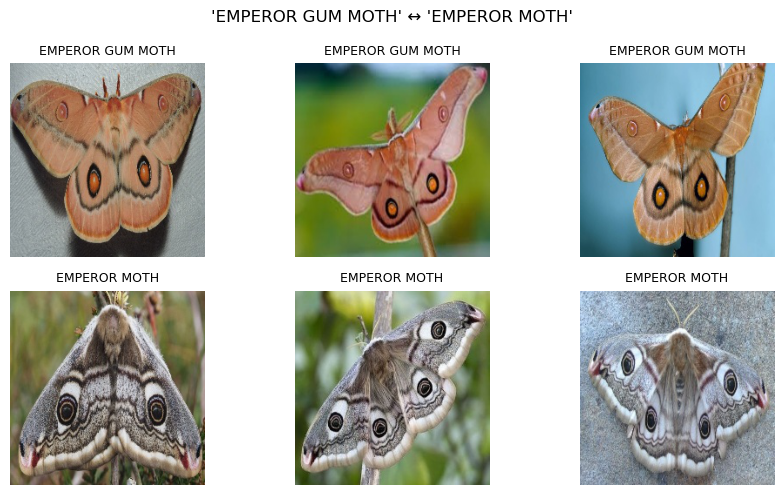


Confused: 'FIERY CLEARWING MOTH' predicted as 'HORNET MOTH'


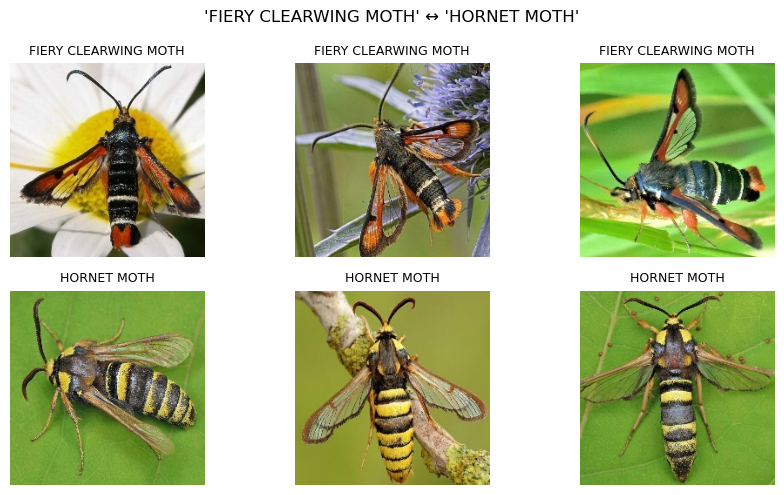


Confused: 'HORNET MOTH' predicted as 'FIERY CLEARWING MOTH'


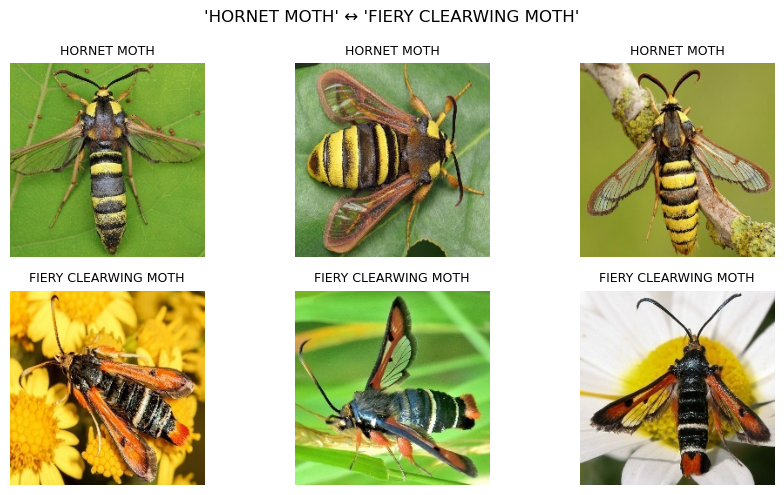


Confused: 'HUMMING BIRD HAWK MOTH' predicted as 'DEATHS HEAD HAWK MOTH'


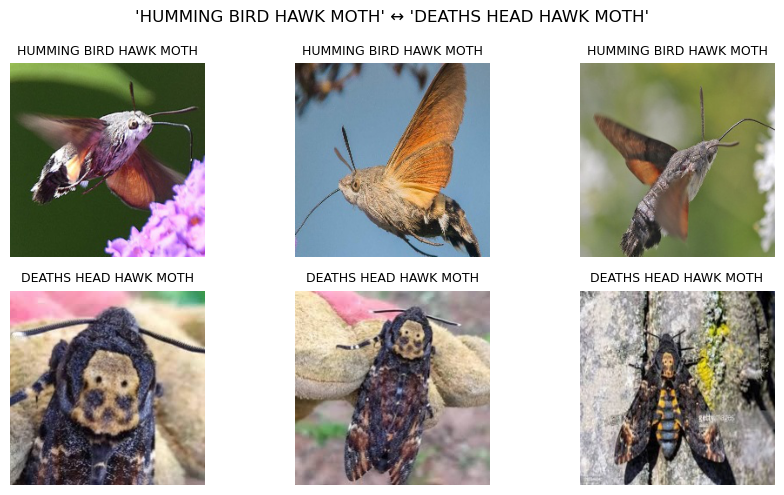


Confused: 'MAGPIE MOTH' predicted as 'GARDEN TIGER MOTH'


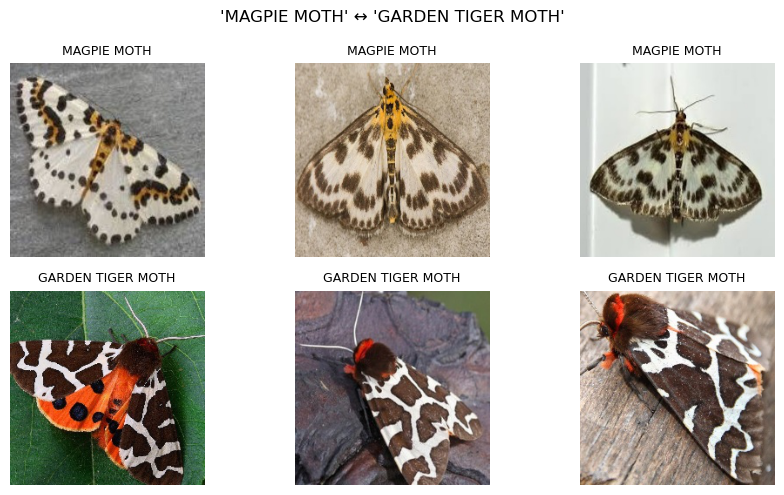


Confused: 'MUSLIN MOTH' predicted as 'BIRD CHERRY ERMINE MOTH'


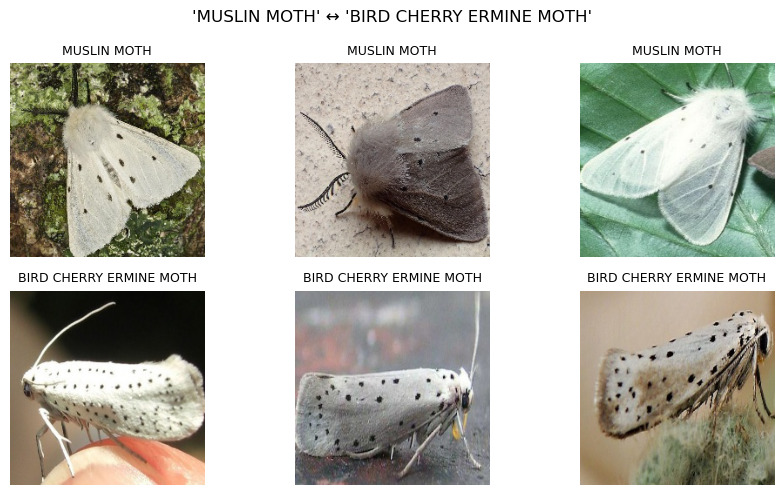


Confused: 'PLUME MOTH' predicted as 'PALPITA VITREALIS MOTH'


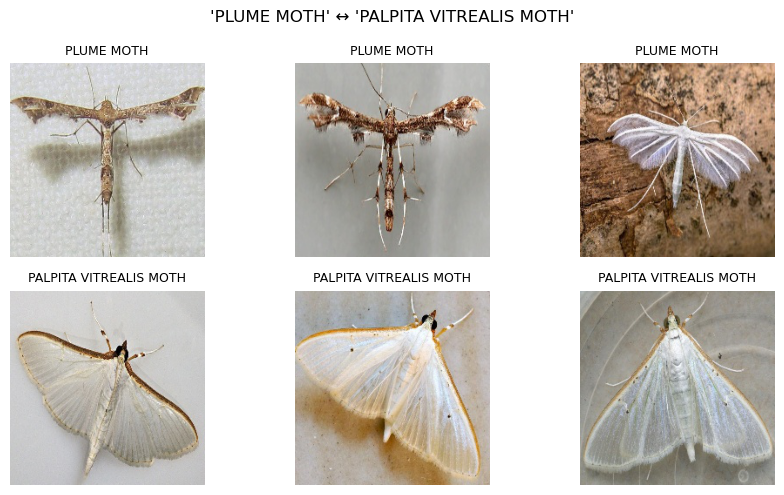


Confused: 'ROSY UNDERWING MOTH' predicted as 'GARDEN TIGER MOTH'


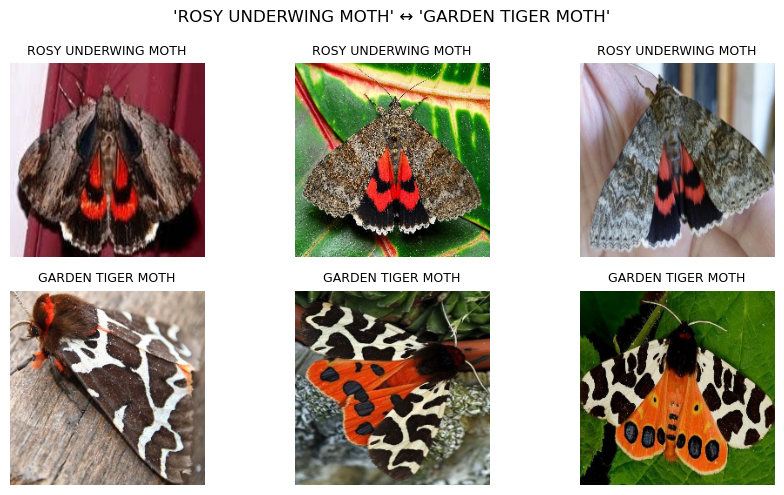


Confused: 'SQUARE SPOT RUSTIC MOTH' predicted as 'BLAIRS MOCHA'


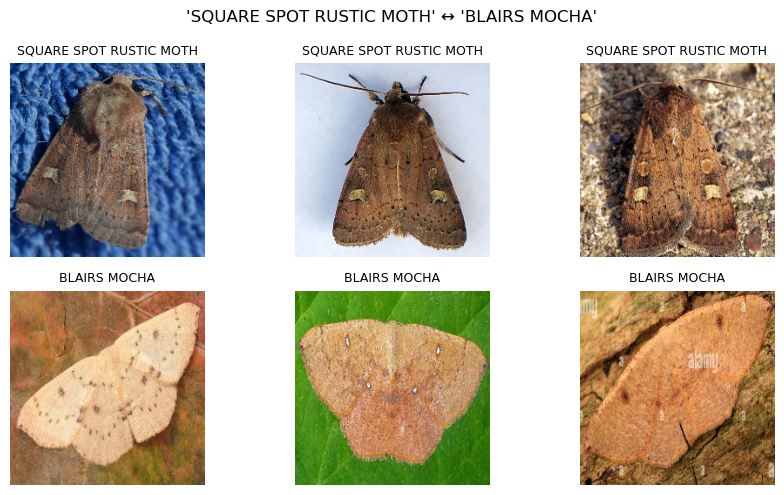

In [2]:
# Define confused class pairs based on the confusion matrix output
confused_pairs_to_plot = [
    ("ARCIGERA FLOWER MOTH", "DEATHS HEAD HAWK MOTH"),
    ("BANDED TIGER MOTH", "GARDEN TIGER MOTH"),
    ("BLAIRS MOCHA", "LACE BORDER MOTH"),
    ("CLEARWING MOTH", "FIERY CLEARWING MOTH"),
    ("EMPEROR GUM MOTH", "EMPEROR MOTH"),
    ("FIERY CLEARWING MOTH", "HORNET MOTH"),
    ("HORNET MOTH", "FIERY CLEARWING MOTH"),
    ("HUMMING BIRD HAWK MOTH", "DEATHS HEAD HAWK MOTH"),
    ("MAGPIE MOTH", "GARDEN TIGER MOTH"),
    ("MUSLIN MOTH", "BIRD CHERRY ERMINE MOTH"),
    ("PLUME MOTH", "PALPITA VITREALIS MOTH"),
    ("ROSY UNDERWING MOTH", "GARDEN TIGER MOTH"),
    ("SQUARE SPOT RUSTIC MOTH", "BLAIRS MOCHA")
]

# Call the visualisation function
show_confused_species("../data/kaggle-dataset/archive", confused_pairs_to_plot)